In [21]:
!pip install EasyGA --no-deps

In [22]:
!pip install matplotlib==3.8.4


In [23]:
import EasyGA
import random

In [24]:
# Define as instâncias das bases de dados
fileName = '/content/f2_l-d_kp_20_878'
capacidade = 878
optimalSolution = 1024

In [25]:
# Faz a leitura do arquivo
peso = []
custo = []
with open(fileName) as f:
    # Ignorar a primeira linha
    next(f)
    for line in f:
      V, W = line.split()
      peso.append(int(W))
      custo.append(int(V))

In [26]:
#Função Fitness
def fitnessFunction(solucao) :
  fitness = 0
  soma_capacidade = 0
  for i in range(len(solucao)) :
    if solucao[i] == 1 :
      fitness += custo[i]
      soma_capacidade += peso[i]
  if soma_capacidade > capacidade:
    #Aplica penalização
    fitness = 0
  return fitness

In [27]:
# Modelagem do GA com o framework
ga = EasyGA.GA()

# Parâmetros: Cromossomo, população, melhor fitness, etc.
ga.population_size = 100
ga.chromosome_length = len(custo)
ga.generation_goal = 500

# Tipo de valor de cada gene
ga.gene_impl = lambda: random.randint(0, 1)

# Tipo de problema de otimização (Max ou Min)
ga.target_fitness_type = 'max'

# Especificar a solução [ótima]
ga.fitness_goal = optimalSolution


In [28]:
# Cadastra a função fitness
ga. fitness_function_impl = fitnessFunction

In [29]:
from EasyGA import crossover, mutation

In [30]:
# Faz a escolha do cruzamento
ga.crossover_individual_impl  = crossover.Crossover.Individual.multi_point
ga.mutation_individual_impl = mutation.Mutation.Individual.individual_genes # default

In [31]:
# Faz a execução do GA
# Imprime a geração e imprime a melhor

while ga.active():
  ga.evolve(20)
  ga.print_generation()
  ga.print_best_chromosome()

Current Generation 	: 20
Best Chromosome 	: [0][1][1][1][1][0][1][1][1][1][1][0][1][0][1][0][1][1][1][0]
Best Fitness    	: 866
Current Generation 	: 40
Best Chromosome 	: [0][1][1][1][1][0][1][1][1][1][1][0][1][0][1][0][1][1][1][0]
Best Fitness    	: 866
Current Generation 	: 60
Best Chromosome 	: [1][0][1][1][1][1][1][1][0][1][1][0][0][1][1][0][1][0][1][1]
Best Fitness    	: 868
Current Generation 	: 80
Best Chromosome 	: [1][0][1][1][1][1][1][1][0][1][1][0][0][1][1][0][1][0][1][1]
Best Fitness    	: 868
Current Generation 	: 100
Best Chromosome 	: [1][0][1][1][1][1][1][1][0][1][1][0][0][1][1][0][1][0][1][1]
Best Fitness    	: 868
Current Generation 	: 120
Best Chromosome 	: [1][0][1][1][1][1][1][1][0][1][1][0][0][1][1][0][1][0][1][1]
Best Fitness    	: 868
Current Generation 	: 140
Best Chromosome 	: [0][0][1][1][1][1][1][0][1][1][1][1][1][1][1][1][1][1][1][0]
Best Fitness    	: 897
Current Generation 	: 160
Best Chromosome 	: [0][0][1][1][1][1][1][0][1][1][1][1][1][1][1][1][1][1][1

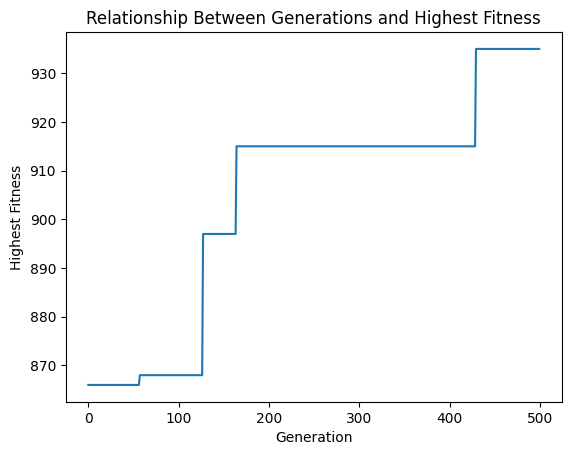

In [32]:
# Mostra a curva
ga.graph.highest_value_chromosome()
ga.graph.show()